In [ ]:
# 참고할 것
# https://sks8410.tistory.com/57

In [1]:
import argparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression

import mlflow
import mlflow.sklearn

In [2]:
# 데이터 로드
csv_path = 'wine_data_homework.csv'

In [3]:
# 1. 데이터 로드
df = pd.read_csv(csv_path)

In [4]:
df.isnull().sum()

Unnamed: 0              0
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [5]:
# 2. 불필요한 인덱스 컬럼 제거  
# CSV에서 자동 생성된 인덱스는 예측에 도움이 안됨
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

In [6]:
print("원본 데이터 크기:", df.shape)
df.head()

원본 데이터 크기: (4001, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [7]:
# 3. 이상치 제거 (IQR 방법)
# 극단적인 값들은 모델 성능을 저하시킬 수 있음
# 각 피처에 대해 IQR(Inter-Quartile Range) 기반 이상치 탐지

# Q1 = df.quantile(0.25)
# Q3 = df.quantile(0.75)
# IQR = Q3 - Q1

In [8]:
# 이상치 범위: Q1 - 1.5*IQR ~ Q3 + 1.5*IQR
# 이 범위를 벗어나는 행은 제거

# outlier_mask = ~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)
# df_clean = df[outlier_mask]
# print(f"이상치 제거 후 데이터 크기: {df_clean.shape} ({df.shape[0] - df_clean.shape[0]}개 행 제거)")


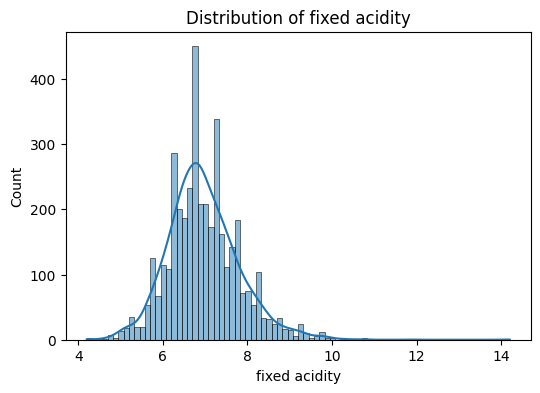

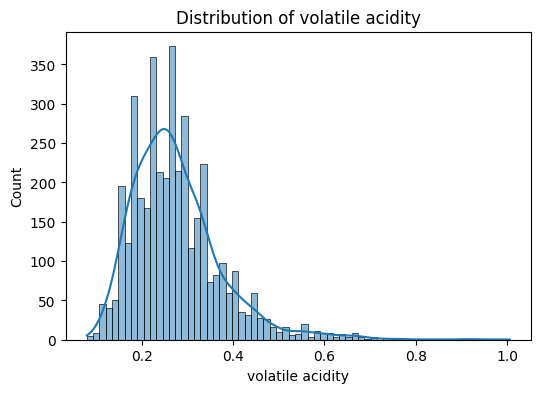

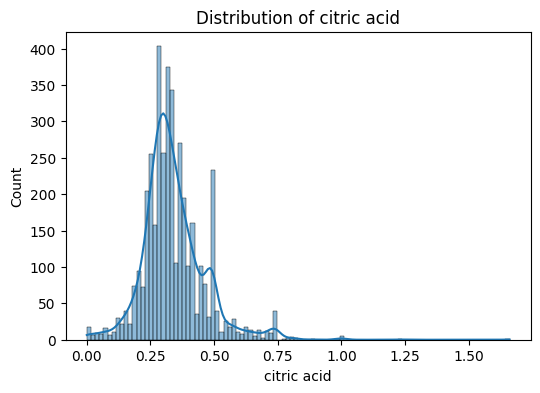

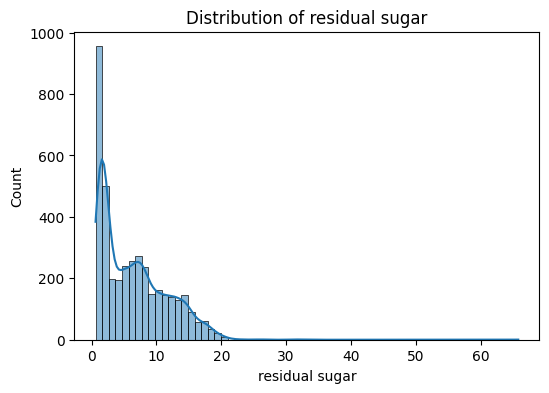

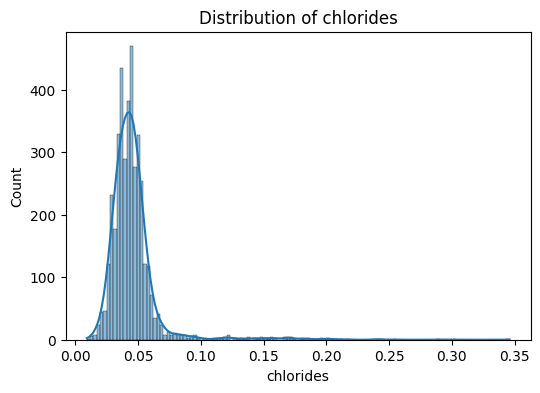

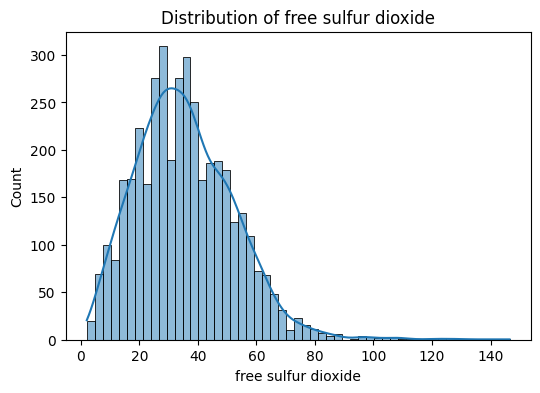

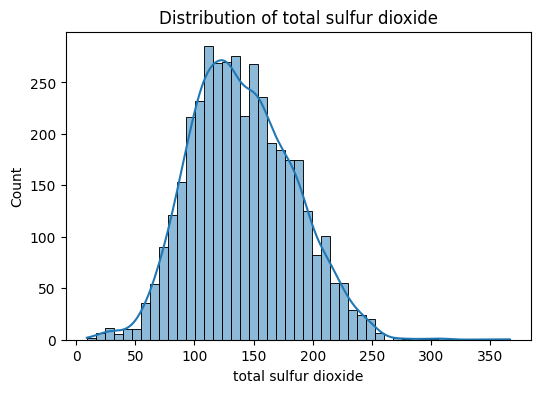

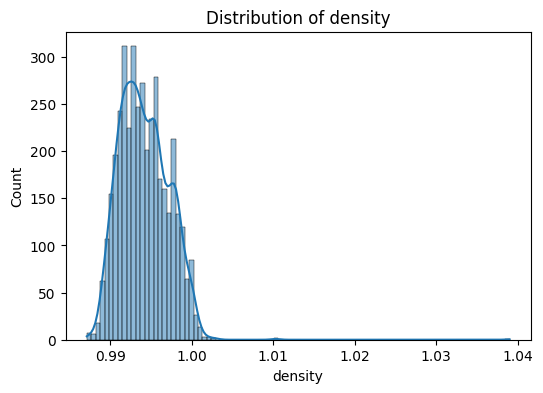

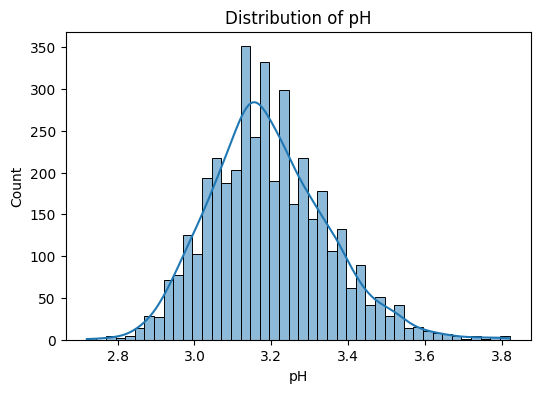

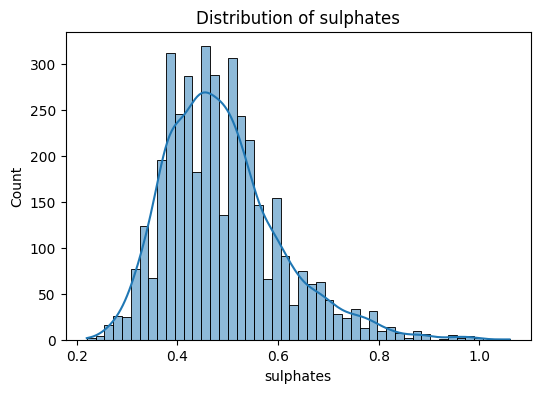

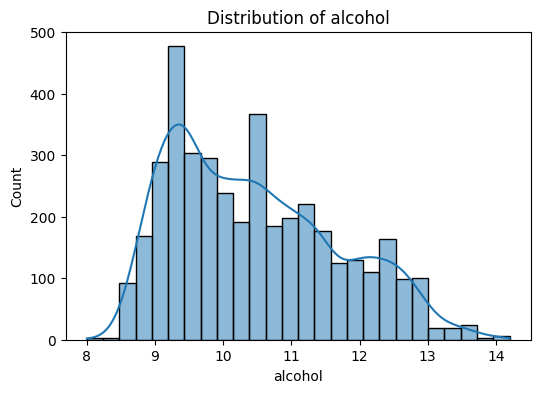

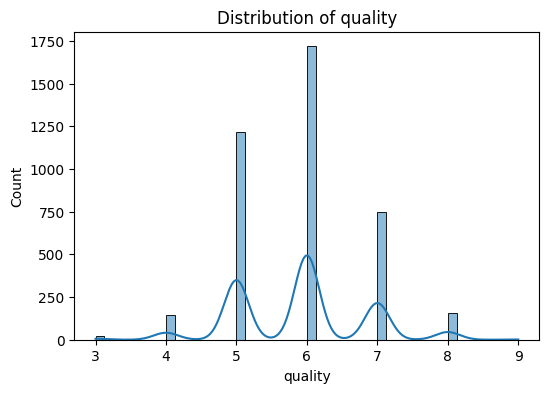

In [10]:
# 3. 한쪽에 치우친 데이터들이 있는지 확인
import matplotlib.pyplot as plt
import seaborn as sns
for column in df.select_dtypes(include=[np.number]).columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.show()

In [11]:
df.describe

<bound method NDFrame.describe of       fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.0              0.27         0.36            20.7      0.045   
1               6.3              0.30         0.34             1.6      0.049   
2               8.1              0.28         0.40             6.9      0.050   
3               7.2              0.23         0.32             8.5      0.058   
4               7.2              0.23         0.32             8.5      0.058   
...             ...               ...          ...             ...        ...   
3996            6.7              0.28         0.34             8.9      0.048   
3997            6.0              0.26         0.29             3.1      0.041   
3998            6.4              0.24         0.49             5.8      0.053   
3999            6.4              0.24         0.49             5.8      0.053   
4000            6.4              0.24         0.49             5.8      0.0

In [12]:
# 4. 이상치 처리 개선: 삭제 대신 로그 변환 (Log Transformation)
# 치우침(Skewness)이 심한 대표적인 컬럼들 선정
skewed_cols = ['residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'sulphates']

# 0 이하의 값이 있을 수 있으므로 np.log1p(log(1+x)) 사용
# 원본 데이터를 보존하기 위해 복사본 생성
df_processed = df.copy()

for col in skewed_cols:
    df_processed[f'{col}_log'] = np.log1p(df_processed[col])
    # 기존 컬럼 제거 (선택 사항, 여기서는 대체)
    df_processed = df_processed.drop(columns=[col])

print("로그 변환 후 컬럼 목록:", df_processed.columns.tolist())

로그 변환 후 컬럼 목록: ['fixed acidity', 'volatile acidity', 'citric acid', 'density', 'pH', 'alcohol', 'quality', 'residual sugar_log', 'chlorides_log', 'free sulfur dioxide_log', 'total sulfur dioxide_log', 'sulphates_log']


In [14]:
# 5. 데이터 분할 (Data Splitting) - 스케일링 전에 수행!
target_col = 'quality'

X = df_processed.drop(columns=[target_col])
y = df_processed[target_col]

# 훈련/테스트 셋 분리 (8:2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")

Train set: (3200, 11), Test set: (801, 11)


In [15]:
# 6. 스케일링 (Scaling) - Data Leakage 방지 방식 적용
scaler = StandardScaler()

# Train set으로만 학습(fit)하고 변환(transform)
X_train_scaled = scaler.fit_transform(X_train)

# Test set은 Train set의 기준(scaler)으로 변환만 수행
X_test_scaled = scaler.transform(X_test)

# (선택 사항) 시각화를 위해 DataFrame으로 다시 변환
X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print("스케일링 완료. X_train 평균(근사치): 0, 분산(근사치): 1")

스케일링 완료. X_train 평균(근사치): 0, 분산(근사치): 1


In [16]:
# 7. 모델 학습 (Random Forest)
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

# 예측
pred_train = rf.predict(X_train_scaled)
pred_test = rf.predict(X_test_scaled)

# 평가
rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))
r2_train = r2_score(y_train, pred_train)
r2_test = r2_score(y_test, pred_test)

print(f"훈련 셋 RMSE: {rmse_train:.4f}, R2: {r2_train:.4f}")
print(f"테스트 셋 RMSE: {rmse_test:.4f}, R2: {r2_test:.4f}")

훈련 셋 RMSE: 0.2371, R2: 0.9325
테스트 셋 RMSE: 0.6249, R2: 0.5176


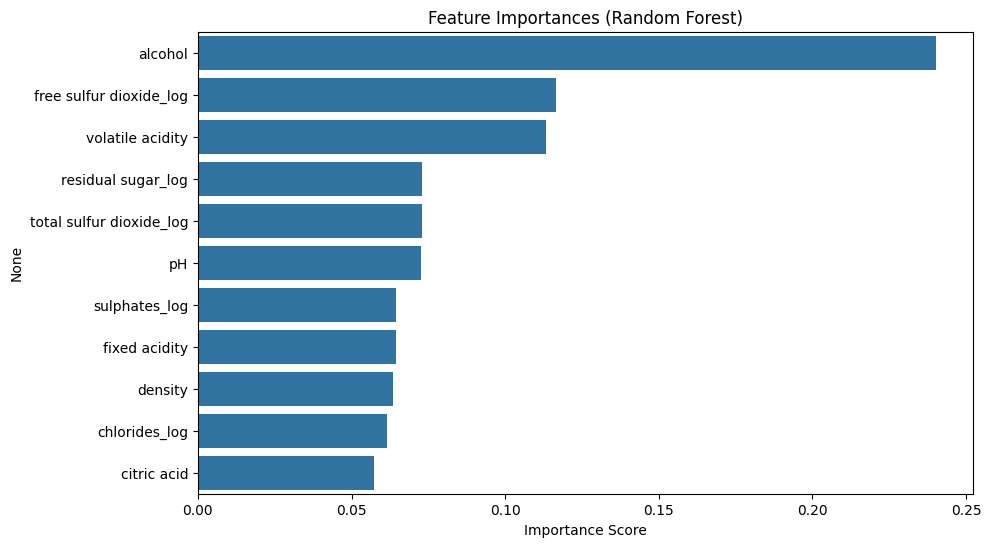

In [17]:
# 8. 피처 중요도 시각화
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.show()

In [ ]:
# StandardScaler로 'residual sugar' 정규화(평균 0, 분산 1) 후 새로운 컬럼에 저장
df_clean = df_clean.copy()  # SettingWithCopy 방지
scaler = StandardScaler()
df_clean['residual sugar_scaled'] = scaler.fit_transform(df_clean[['residual sugar']])

# 결과 확인
print(df_clean[['residual sugar', 'residual sugar_scaled']].head())
print("scaled mean:", df_clean['residual sugar_scaled'].mean(), "scaled std:", df_clean['residual sugar_scaled'].std())

In [ ]:
# 1. 컬럼 정의
target_col = 'quality'  # 타겟 변수
orig_residual = 'residual sugar'  # 제거할 원본 컬럼
keep_scaled_residual = 'residual sugar_scaled'  # 이미 스케일링되어 유지할 컬럼

# 2. 스케일링 대상 피처 선정
# df_clean의 숫자형 컬럼 중, 타겟, 원본 residual sugar, 이미 스케일링된 residual sugar를 제외한 모든 컬럼을 선택합니다.
features_to_scale = [
    col for col in df_clean.select_dtypes(include=np.number).columns
    if col not in [target_col, orig_residual, keep_scaled_residual]
]

# 3. 스케일링 적용 및 새 DataFrame 생성
# StandardScaler를 사용해 선택된 피처들을 표준화(평균 0, 표준편차 1)합니다.
scaler = StandardScaler()
scaled_features_array = scaler.fit_transform(df_clean[features_to_scale])

# 스케일링된 데이터를 Pandas DataFrame으로 변환합니다.
# 컬럼명은 기존 이름에 '_scaled' 접미사를 붙여주고, 인덱스는 원본 df_clean의 것을 유지합니다.
df_newly_scaled = pd.DataFrame(
    scaled_features_array,
    columns=[f"{col}_scaled" for col in features_to_scale],
    index=df_clean.index
)

# 4. 최종 DataFrame 조합
# df_clean에서 유지해야 할 컬럼(이미 스케일링된 residual sugar, 타겟)과
# 새로 스케일링된 피처 DataFrame을横으로 결합합니다.
# 원본 'residual sugar' 컬럼과 스케일링 대상이 되었던 원본 피처들은 자연스럽게 제외됩니다.
df_processed = pd.concat(
    [df_clean[[keep_scaled_residual, target_col]], df_newly_scaled],
    axis=1
)

#--- 전처리 완료 ---

# 5. 결과 확인
print("전처리 전 df_clean shape:", df_clean.shape)
print("전처리 후 df_processed shape:", df_processed.shape)
print("최종 컬럼 목록:", df_processed.columns.tolist())
df_processed.head()

In [ ]:
# 시각화 + 간단한 분석/로그 남기기 (df_processed, column 등 기존 변수를 사용)
# 필요 모듈(이미 노트북에서 import됨): plt, sns, np, train_test_split, RandomForestRegressor, SelectKBest, f_regression, mlflow, mlflow.sklearn

# 요약 정보 출력
print("df_processed shape:", df_processed.shape)
print("columns:", df_processed.columns.tolist())
print("\n기본 통계 요약:\n", df_processed.describe().T)

# 상관관계: target과의 관계 강한 피처 출력 및 히트맵
corr = df_processed.corr()
target_col = column  # notebook에 이미 정의된 변수 사용 ('quality')
target_corr = corr[target_col].drop(target_col).sort_values(key=lambda s: s.abs(), ascending=False)
print("\nTarget과의 상관도 (절대값 내림차순):\n", target_corr)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation matrix (df_processed)')
plt.show()

# 타겟 분포와 상위 몇 개 피처의 분포(히스토그램)
plt.figure(figsize=(6,4))
sns.histplot(df_processed[target_col], kde=True)
plt.title(f'Distribution of {target_col}')
plt.show()

top_feats = target_corr.index[:5].tolist()  # target과 가장 관련 있는 상위 5개 피처
print("Top features related to target:", top_feats)

# pairplot (상위 피처들 + target) — 데이터 양이 많아 느릴 수 있으므로 샘플링
pairplot_cols = top_feats + [target_col]
sample = df_processed[pairplot_cols].sample(n=min(800, len(df_processed)), random_state=42)
try:
    sns.pairplot(sample, diag_kind='kde', corner=True)
    plt.suptitle('Pairplot of top features vs target', y=1.02)
    plt.show()
except Exception as e:
    print("Pairplot skipped or failed:", e)

# 박스플롯들: 스케일된 피처들에서 이상치 확인 (그리드로 출력)
features = [c for c in df_processed.columns if c != target_col]
n = len(features)
cols = 3
rows = (n + cols - 1) // cols
plt.figure(figsize=(cols*5, rows*3.5))
for i, f in enumerate(features, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=df_processed[f])
    plt.title(f)
plt.tight_layout()
plt.show()

# 통계 기반 피처 스코어 (SelectKBest 사용, k='all'로 점수 확인)
X_feats = df_processed.drop(columns=[target_col])
y = df_processed[target_col].values
skb = SelectKBest(score_func=f_regression, k='all')
scores = skb.fit(X_feats, y).scores_
scores_series = pd.Series(scores, index=X_feats.columns).sort_values(ascending=False)
print("\nSelectKBest F-scores (desc):\n", scores_series)

# 간단한 모델 학습 및 성능 로깅 (RandomForest)
X = X_feats.values
from sklearn.model_selection import train_test_split  # 이미 import 되어 있을 수 있음, 안전하게 사용
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)
print(f"\nRandomForest 성능: RMSE = {rmse:.4f}, R2 = {r2:.4f}")

# feature importance
feat_importances = pd.Series(rf.feature_importances_, index=X_feats.columns).sort_values(ascending=False)
print("\nRandomForest feature importances:\n", feat_importances)

# mlflow에 로깅 (실행이 열려있다면 로그됨)
try:
    mlflow.log_metric("rmse", float(rmse))
    mlflow.log_metric("r2", float(r2))
    # 상위 중요 피처 10개 로깅
    for i, (fname, val) in enumerate(feat_importances.head(10).items(), 1):
        mlflow.log_metric(f"feat_imp_{i}_{fname}", float(val))
    # 모델 로깅 (선택)
    mlflow.sklearn.log_model(rf, "random_forest_model")
    print("Metrics and model logged to mlflow.")
except Exception as e:
    print("mlflow logging skipped or failed:", e)

print("\n분석 완료.")

In [ ]:
# 전처리: 모든 수치형 피처에 대해 필요하면 정규화하고,
# 이미 존재하는 residual sugar_scaled 를 유지한 채 원래 residual sugar 컬럼은 제거합니다.

# target 컬럼명 (이미 정의된 변수 사용)
target_col = 'quality'  # 'quality'

# 숫자형 컬럼 목록
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

# 유지 / 제외할 컬럼들
keep_scaled = 'residual sugar_scaled'
orig_residual = 'residual sugar'

# 스케일링할 피처: 숫자형이면서 target, residual sugar_scaled, 원본 residual sugar은 제외
features_to_scale = [c for c in num_cols if c not in (target_col, keep_scaled, orig_residual)]

# 스케일러 생성 및 적용
scaler_numeric = StandardScaler()
scaled_array = scaler_numeric.fit_transform(df_clean[features_to_scale])

# 스케일된 컬럼명은 원래 이름 + '_scaled'
scaled_cols = [f"{c}_scaled" for c in features_to_scale]
df_scaled = pd.DataFrame(scaled_array, columns=scaled_cols, index=df_clean.index)

# 최종 데이터프레임 구성: 기존 residual sugar_scaled 유지, 새로 스케일된 컬럼 추가, target 추가
df_processed = pd.concat([df_clean[[keep_scaled, target_col]].reset_index(drop=True),
                          df_scaled.reset_index(drop=True)], axis=1)

# 원본 residual sugar 컬럼 제거는 이미 처리: df_processed에는 포함되지 않음
print("원본 df_clean shape:", df_clean.shape)
print("전처리 후 df_processed shape:", df_processed.shape)
print("컬럼 목록:", df_processed.columns.tolist())
df_processed.head()

In [ ]:
# 시각화 + 간단한 분석/로그 남기기 (df_processed, column 등 기존 변수를 사용)
# 필요 모듈(이미 노트북에서 import됨): plt, sns, np, train_test_split, RandomForestRegressor, SelectKBest, f_regression, mlflow, mlflow.sklearn

# 요약 정보 출력
print("df_processed shape:", df_processed.shape)
print("columns:", df_processed.columns.tolist())
print("\n기본 통계 요약:\n", df_processed.describe().T)

# 상관관계: target과의 관계 강한 피처 출력 및 히트맵
corr = df_processed.corr()
target_col = column  # notebook에 이미 정의된 변수 사용 ('quality')
target_corr = corr[target_col].drop(target_col).sort_values(key=lambda s: s.abs(), ascending=False)
print("\nTarget과의 상관도 (절대값 내림차순):\n", target_corr)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation matrix (df_processed)')
plt.show()

# 타겟 분포와 상위 몇 개 피처의 분포(히스토그램)
plt.figure(figsize=(6,4))
sns.histplot(df_processed[target_col], kde=True)
plt.title(f'Distribution of {target_col}')
plt.show()

top_feats = target_corr.index[:5].tolist()  # target과 가장 관련 있는 상위 5개 피처
print("Top features related to target:", top_feats)

# pairplot (상위 피처들 + target) — 데이터 양이 많아 느릴 수 있으므로 샘플링
pairplot_cols = top_feats + [target_col]
sample = df_processed[pairplot_cols].sample(n=min(800, len(df_processed)), random_state=42)
try:
    sns.pairplot(sample, diag_kind='kde', corner=True)
    plt.suptitle('Pairplot of top features vs target', y=1.02)
    plt.show()
except Exception as e:
    print("Pairplot skipped or failed:", e)

# 박스플롯들: 스케일된 피처들에서 이상치 확인 (그리드로 출력)
features = [c for c in df_processed.columns if c != target_col]
n = len(features)
cols = 3
rows = (n + cols - 1) // cols
plt.figure(figsize=(cols*5, rows*3.5))
for i, f in enumerate(features, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=df_processed[f])
    plt.title(f)
plt.tight_layout()
plt.show()

# 통계 기반 피처 스코어 (SelectKBest 사용, k='all'로 점수 확인)
X_feats = df_processed.drop(columns=[target_col])
y = df_processed[target_col].values
skb = SelectKBest(score_func=f_regression, k='all')
scores = skb.fit(X_feats, y).scores_
scores_series = pd.Series(scores, index=X_feats.columns).sort_values(ascending=False)
print("\nSelectKBest F-scores (desc):\n", scores_series)

# 간단한 모델 학습 및 성능 로깅 (RandomForest)
X = X_feats.values
from sklearn.model_selection import train_test_split  # 이미 import 되어 있을 수 있음, 안전하게 사용
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)

rmse = mean_squared_error(y_test, pred, squared=False)
r2 = r2_score(y_test, pred)
print(f"\nRandomForest 성능: RMSE = {rmse:.4f}, R2 = {r2:.4f}")

# feature importance
feat_importances = pd.Series(rf.feature_importances_, index=X_feats.columns).sort_values(ascending=False)
print("\nRandomForest feature importances:\n", feat_importances)

# mlflow에 로깅 (실행이 열려있다면 로그됨)
try:
    mlflow.log_metric("rmse", float(rmse))
    mlflow.log_metric("r2", float(r2))
    # 상위 중요 피처 10개 로깅
    for i, (fname, val) in enumerate(feat_importances.head(10).items(), 1):
        mlflow.log_metric(f"feat_imp_{i}_{fname}", float(val))
    # 모델 로깅 (선택)
    mlflow.sklearn.log_model(rf, "random_forest_model")
    print("Metrics and model logged to mlflow.")
except Exception as e:
    print("mlflow logging skipped or failed:", e)

print("\n분석 완료.")